# Prompt U-Net Version 332_h — Final Model trained only on head

## Summary

**V332 is the final benchmark-selected model**, combining the best individual choices from prior ablations. This time only on head mri data and 3000 epochs for faster training

| Component | Choice | Source |
|-----------|--------|--------|
| Architecture | `prompt_unet_313.py` (Float32 + SE Attention) | v316 / v313 |
| Offset | 16 | v316 |
| Loss | `binary_crossentropy` (plain BCE) | v316 — beats DiceBCE in benchmarks |
| Training buffer | 10,000 data points | v330 / v331 |
| Refresh cadence | every 30 epochs (slightly less aggressive than v330/v331's 20) | new |
| Datasets | **NAKO (Brain only) + TopCow + Brats_Mets** | / |
| Total patients | 208 | v319 |
| Epochs | **3000** | / |

All hyper-parameters are read from the **Hyperparameters** cell below — edit there only.

> This notebook can also be run headless via `train_332.py` in the same directory.

## Setup

In [1]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1778751443.259709     107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778751443.323709     107 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778751452.256155     107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF  : 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Imports

In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from training.prompt_unet_313 import PromptUNet   # v313 architecture (Float32 + SE Attention)
from training.optimizer       import PromptUNetOptimizer

## Data Loading

208 patients total (v316 base + TopCoW from v319).

In [3]:
dataset_paths = [
    "data/train_data/nako_head.npz",       
    "data/train_data/TopCoW_CT.npz",
    "data/train_data/TopCoW_MR.npz",
    "data/train_data/brats_gli.npz",
    "data/train_data/brats_men_rt.npz",
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 57 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_head.npz
Loaded 18 PIDs from /home/dpxuser/prompt-unet/data/train_data/TopCoW_CT.npz
Loaded 18 PIDs from /home/dpxuser/prompt-unet/data/train_data/TopCoW_MR.npz
Loaded 20 PIDs from /home/dpxuser/prompt-unet/data/train_data/brats_gli.npz
Loaded 6 PIDs from /home/dpxuser/prompt-unet/data/train_data/brats_men_rt.npz

Final dataset size: 119 patients.

Image size: 128 x 128


## Hyperparameters

In [4]:
version           = "p_unet_332_h"

epochs            = 3000
batch_size        = 128
dp_training       = 10000  # 10 k points per buffer refresh (from v330)
dp_testing        = 1000

offset            = 16     # slice-distance offset (from v316)
max_number_labels = 4

new_ds       = 30    # refresh training data every N epochs (slightly less aggressive than v330/v331's 20)
new_val_loop = 300   # run validation every N epochs

# LR schedule phases
warmup_epochs = 50
flat_epochs   = 1500

## Model & Optimizer

`WarmupFlatCosineDecay` schedule (from `optimizer.py`):
- Phase 1 (50 ep): linear warmup 1e-6 → 1e-3  
- Phase 2 (1500 ep): flat plateau at 1e-3  
- Phase 3 (2450 ep): cosine decay 1e-3 → 1e-5

Loss: **plain `binary_crossentropy`** — reverted from DiceBCE (v316 outperforms v330/v331 in benchmarks).

In [5]:
# ── Build model ────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)
# Loss stays as default binary_crossentropy (set inside PromptUNet.__init__)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── Build optimizer (imported from optimizer.py) ───────────────────────────
opt_builder = PromptUNetOptimizer(
    epochs        = epochs,
    batch_size    = batch_size,
    dp_training   = dp_training,
    warmup_epochs = warmup_epochs,
    flat_epochs   = flat_epochs,
)
model.optimizer   = opt_builder.get_optimizer()
steps_per_epoch   = opt_builder.steps_per_epoch

I0000 00:00:1778751470.348466     107 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ab:00.0, compute capability: 8.9
I0000 00:00:1778751472.352646     107 cuda_dnn.cc:461] Loaded cuDNN version 90500


Trainable params: 28,037,637


## Augmentation Pipeline

Same probabilities as v313–v316.

In [6]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.35,
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.50,
    prob_morph             = 0.30,
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    gamma_range                 = (0.85, 1.25),
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.  
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time.

In [7]:
# ── Shared numpy buffer ────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

/software/anaconda3/envs/machauer/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Creating new Data Points ...
It took 3 seconds
Creating new Data Points ...
It took 33 seconds


I0000 00:00:1778751520.946793     107 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
E0000 00:00:1778751532.489671     107 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch    1  loss: 0.580884
Epoch    2  loss: 0.349038
Epoch    3  loss: 0.262239
Epoch    4  loss: 0.231137
Epoch    5  loss: 0.211269
Epoch    6  loss: 0.194701
Epoch    7  loss: 0.178584
Epoch    8  loss: 0.164390
Epoch    9  loss: 0.151028
Epoch   10  loss: 0.139107
Epoch   11  loss: 0.128481
Epoch   12  loss: 0.118168
Epoch   13  loss: 0.110026
Epoch   14  loss: 0.102681
Epoch   15  loss: 0.097070
Epoch   16  loss: 0.091858
Epoch   17  loss: 0.087766
Epoch   18  loss: 0.083705
Epoch   19  loss: 0.080724
Epoch   20  loss: 0.078595
Epoch   21  loss: 0.075895
Epoch   22  loss: 0.074158
Epoch   23  loss: 0.071599
Epoch   24  loss: 0.071000
Epoch   25  loss: 0.069891
Epoch   26  loss: 0.068432
Epoch   27  loss: 0.067911
Epoch   28  loss: 0.067106
Epoch   29  loss: 0.065980
Epoch   30  loss: 0.065348


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.0295618].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.0295618].


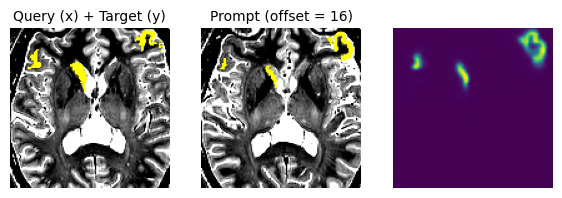

Creating new Data Points ...
It took 29 seconds
Epoch   31  loss: 0.058873
Epoch   32  loss: 0.058012
Epoch   33  loss: 0.057240
Epoch   34  loss: 0.056601
Epoch   35  loss: 0.055762
Epoch   36  loss: 0.056003
Epoch   37  loss: 0.055070
Epoch   38  loss: 0.054262
Epoch   39  loss: 0.054751
Epoch   40  loss: 0.054193
Epoch   41  loss: 0.054456
Epoch   42  loss: 0.053642
Epoch   43  loss: 0.053726
Epoch   44  loss: 0.052918
Epoch   45  loss: 0.052446
Epoch   46  loss: 0.051982
Epoch   47  loss: 0.052092
Epoch   48  loss: 0.051521
Epoch   49  loss: 0.051617
Epoch   50  loss: 0.051043
Epoch   51  loss: 0.050880
Epoch   52  loss: 0.051023
Epoch   53  loss: 0.050583
Epoch   54  loss: 0.050437
Epoch   55  loss: 0.049731
Epoch   56  loss: 0.049622
Epoch   57  loss: 0.049523
Epoch   58  loss: 0.048790
Epoch   59  loss: 0.048604
Epoch   60  loss: 0.048491


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.0295618].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.0295618].


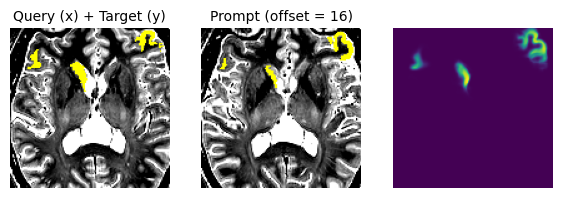

Creating new Data Points ...
It took 27 seconds
Epoch   61  loss: 0.054044
Epoch   62  loss: 0.052600
Epoch   63  loss: 0.053127
Epoch   64  loss: 0.051943
Epoch   65  loss: 0.052205


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
            "new_ds"            : new_ds,
            "warmup_epochs"     : warmup_epochs,
            "flat_epochs"       : flat_epochs,
            "prob_geometric"    : augmenter.prob_geometric,
            "prob_morph"        : augmenter.prob_morph,
            "gamma_range"       : str(augmenter.gamma_range),
            "trainable_params"  : model.this.count_params(),
            "scale_augmentation": "50% crop 128px / 50% crop [128,256]px resized",
            "leakage_fix"       : "crop origin from support label only",
            "se_attention"      : "enabled",
            "mixed_precision"   : "false",
            "datasets"          : "nako+total_seg+msd+brats_gli+brats_men_rt+TopCoW_MR+TopCoW_CT",
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)